In [1]:
# Importing Libararies 

import pandas as pd  
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [3]:
# Data Import 

df = sns.load_dataset('titanic')

In [4]:
# Check the data 
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


## Missing Values and Imputing them 

In [5]:
# Find out the percantage of the missing values  

df.isnull().sum() / len (df) * 100

survived        0.000000
pclass          0.000000
sex             0.000000
age            19.865320
sibsp           0.000000
parch           0.000000
fare            0.000000
embarked        0.224467
class           0.000000
who             0.000000
adult_male      0.000000
deck           77.216611
embark_town     0.224467
alive           0.000000
alone           0.000000
dtype: float64

In [6]:
# Drop the Highest missing values Column from data set 

df.drop('deck', axis=1, inplace=True)

In [7]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='str')

In [8]:
# Fillimg the missing Values of column by mean of column 

df['age'] = df['age'].fillna(df['age'].mean())

In [9]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       2
class          0
who            0
adult_male     0
embark_town    2
alive          0
alone          0
dtype: int64

In [10]:
# Fill embark and embark_town with mode 
df['embarked'] = df['embarked'].fillna(df['embarked'].mode()[0])
df['embark_town'] = df['embark_town'].fillna(df['embark_town'].mode()[0])


In [11]:
df.isnull().sum()

survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64

<Axes: >

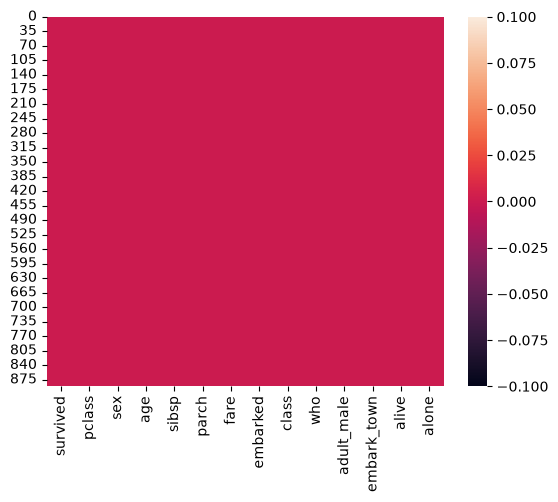

In [11]:
sns.heatmap(df.isnull())

# Assigment: if you do not impute missing values what will happen ?

# Binning 

In [12]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [13]:
df.age.min()

np.float64(0.42)

In [14]:
df.age.max()

np.float64(80.0)

<Axes: xlabel='age', ylabel='Count'>

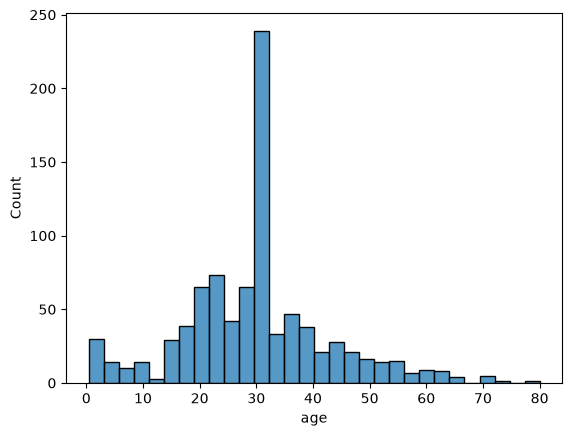

In [15]:
sns.histplot(df['age'])

In [16]:
# Binning of Age column into 7  catogeries 

bins = [0,1,5,12,18,30, 50, 80]

labels = ['infans', 'Todelers', 'kids', 'Teens','Youngs', 'Middle Age', 'Old']

# Kis Column ko bin main convert krna hai 
pd.cut(df['age'], bins=bins, labels=labels)

0          Youngs
1      Middle Age
2          Youngs
3      Middle Age
4      Middle Age
          ...    
886        Youngs
887        Youngs
888        Youngs
889        Youngs
890    Middle Age
Name: age, Length: 891, dtype: category
Categories (7, str): ['infans' < 'Todelers' < 'kids' < 'Teens' < 'Youngs' < 'Middle Age' < 'Old']

In [17]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [18]:
# Feature Engineering 

bins = [0,1,5,12,18,30, 50, 80]

labels = ['infans', 'Todelers', 'kids', 'Teens','Youngs', 'Middle Age', 'Old']

# Kis Column ko bin main convert krna hai 
df['binned_age'] = pd.cut(df['age'], bins=bins, labels=labels)  


In [28]:
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,binned_age
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Age
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Age
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Age


In [27]:
df['binned_age'].value_counts()

binned_age
Youngs        447
Middle Age    241
Teens          70
Old            64
Todelers       30
kids           25
infans         14
Name: count, dtype: int64

# Reanaming a column 

In [29]:
df.rename(columns = {'binned_age': 'age_groups'})

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone,age_groups
0,0,3,male,22.000000,1,0,7.2500,S,Third,man,True,Southampton,no,False,Youngs
1,1,1,female,38.000000,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False,Middle Age
2,1,3,female,26.000000,0,0,7.9250,S,Third,woman,False,Southampton,yes,True,Youngs
3,1,1,female,35.000000,1,0,53.1000,S,First,woman,False,Southampton,yes,False,Middle Age
4,0,3,male,35.000000,0,0,8.0500,S,Third,man,True,Southampton,no,True,Middle Age
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,2,male,27.000000,0,0,13.0000,S,Second,man,True,Southampton,no,True,Youngs
887,1,1,female,19.000000,0,0,30.0000,S,First,woman,False,Southampton,yes,True,Youngs
888,0,3,female,29.699118,1,2,23.4500,S,Third,woman,False,Southampton,no,False,Youngs
889,1,1,male,26.000000,0,0,30.0000,C,First,man,True,Cherbourg,yes,True,Youngs


## Data Filteration 

In [32]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone', 'binned_age'],
      dtype='str')

In [ ]:
df_01 = df[['survived', 'binned_age', 'fare', 'class']]



In [35]:
df_01.head()

,survived,binned_age,fare,class
0,0,Youngs,7.2500,Third
1,1,Middle Age,71.2833,First
2,1,Youngs,7.9250,Third
3,1,Middle Age,53.1000,First
4,0,Middle Age,8.0500,Third


In [36]:
# Filter the data based on rows crietria 

df_01[df_01['class']=='First']

,survived,binned_age,fare,class
1,1,Middle Age,71.2833,First
3,1,Middle Age,53.1000,First
6,0,Old,51.8625,First
11,1,Old,26.5500,First
23,1,Youngs,35.5000,First
...,...,...,...,...
871,1,Middle Age,52.5542,First
872,0,Middle Age,5.0000,First
879,1,Old,83.1583,First
887,1,Youngs,30.0000,First


In [44]:
# Lets select only those rows which have paid more then 200 pounds 

df_200 = df_01[df_01['fare'] > 50]

In [45]:
df_200.info()

<class 'pandas.DataFrame'>
Index: 160 entries, 1 to 879
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   survived    160 non-null    int64   
 1   binned_age  160 non-null    category
 2   fare        160 non-null    float64 
 3   class       160 non-null    category
dtypes: category(2), float64(1), int64(1)
memory usage: 4.5 KB


In [46]:
df_200 ['class'].value_counts()

class
First     139
Third      14
Second      7
Name: count, dtype: int64

In [50]:
# how to filter two columns 
df_01[(df_01['fare'] > 70) | (df_01['class'] == 'First')]

,survived,binned_age,fare,class
1,1,Middle Age,71.2833,First
3,1,Middle Age,53.1000,First
6,0,Old,51.8625,First
11,1,Old,26.5500,First
23,1,Youngs,35.5000,First
...,...,...,...,...
871,1,Middle Age,52.5542,First
872,0,Middle Age,5.0000,First
879,1,Old,83.1583,First
887,1,Youngs,30.0000,First
